# IN3050/IN4050 Mandatory Assignment 3: Unsupervised Learning

**Name:** Nikita

**Username:** Nikitafe

### Rules

Before you begin the exercise, review the rules at this website: https://www.uio.no/english/studies/examinations/compulsory-activities/mn-ifi-mandatory.html , in particular the paragraph on cooperation. This is an individual assignment. You are not allowed to deliver together or copy/share source-code/answers with others. Read also the "Routines for handling suspicion of cheating and attempted cheating at the University of Oslo": https://www.uio.no/english/studies/examinations/cheating/index.html 
We do not entirely prohibit the use of generative language models ("smart assistants" like ChatGPT, Llama, Claude or Copilot), but you must clearly acknowledge this at all times, following the UiO guidelines: https://www.uio.no/english/studies/resources/ai_student.html
Note also that you must fully understand _all_ the parts of you submissions, even if you got some help from a generative model. This will be tested during your peer review sessions (https://www.uio.no/studier/emner/matnat/ifi/IN3050/v25/Peer%20review/).
By submitting this assignment, you confirm that you are familiar with the rules and the consequences of breaking them.

### Delivery

**Deadline**: Tuesday, April 22, 2025, 23:59 CEST

Your submission should be delivered in Devilry. You may make several submissions in Devilry before the deadline, but only the last delivery will be read, so make sure to include all files in the last delivery. It is recommended to upload preliminary versions hours (or days) before the final deadline.

### What to deliver?

We recommend you to solve all exercises in this Jupyter notebook (alternative 1), but it is also possible to work with a regular Python script (alternative 2).

**Alternative 1:** If you choose Jupyter, you should deliver the notebook. You should answer all questions and explain what you are doing in Markdown. Still, the code should be properly commented. The notebook should contain results of your runs. In addition, you also have to submit a PDF of your solution which shows the results of the runs.

**Alternative 2:** If you prefer not to use notebooks, you should deliver the code as Python scripts together with your run results and a PDF report where you answer all the questions and explain your work.

Here is a list of *absolutely necessary* (but not sufficient) conditions to get the assignment marked as passed:

- You must deliver your code (Python script or Jupyter notebook) you used to solve the assignment.
- The code used for making the output and plots must be included in the assignment. 
- You must include example runs that clearly shows how to run all implemented functions and methods.
- All the code (in notebook cells or python main-blocks) must be runnable. If you have unfinished code that crashes, please comment it out and document what you think causes it to crash. 
- You must also deliver a PDF of the code, outputs, comments and plots as explained above.

Make sure to include your name and username in the submitted files. Deliver one single compressed folder (.zip, .tgz or .tar.gz) which contains your complete solution.

Important: if you weren’t able to finish the assignment, use the PDF report/Markdown to elaborate on what you’ve tried and what problems you encountered. Students who have made an effort and attempted all parts of the assignment will get a second chance even if they fail initially. This exercise will be graded PASS/FAIL.

### Goals of the assignment
This assignment has two parts:
1. You will go through the basic theory of **Principal Component Analysis (PCA)** and implement PCA from scratch to compress and visualize data.
2. You will run **K-means clustering** using the `scikit-learn` toolkit and use PCA to visualize the results. You will also evaluate the output of K-means using a multi-class logistic regression classifier.

IN4050 students will have to do one extra part about tuning PCA to balance compression with information lost.

### Tools
You may freely use code from the weekly exercises and the published solutions. In the first part about PCA you may **NOT** use ML libraries like `scikit-learn`. In the K-means part and beyond we encourage the use of `scikit-learn` to iterate quickly on the problems.

We will use the *numpy* library for performing matrix computations and the *pyplot* library for plotting data, as well as *scikit-learn* for K-means clustering. This assignment also comes with a module called *data_assignment3* that you will use to import different (synthetic and real) datasets. Let's start by making sure that everything is installed.

In [2]:
%pip install numpy matplotlib scikit-learn

import data_assignment3

Note: you may need to restart the kernel to use updated packages.


# Part 1: Principal Component Analysis (PCA)
In this section, you will work with the PCA algorithm in order to understand its definition and explore its uses.

## Part 1.1: Implementation
Here we implement the basic steps of PCA and we assemble them. We will only need functions from *numpy* for this part.

In [3]:
import numpy as np

### Centering the Data
Implement a function with the following signature to center the data. Remember that every *feature* should be centered.

In [4]:
def center_data(A):
    # Compute the mean of each feature (column-wise mean)
    mean_A = np.mean(A, axis=0)
    # Subtract the mean from each feature to center the data
    X = A - mean_A
    return X

    return None

Test your function checking the following assertion on *testcase* (absence of output means that the assertion holds):

In [5]:
testcase = np.array([[3., 11., 4.3], [4., 5., 4.3], [5., 17., 4.5], [4, 13., 4.4]])
answer = np.array([[-1., -0.5, -0.075], [0., -6.5, -0.075], [1., 5.5, 0.125], [0., 1.5, 0.025]])
np.testing.assert_array_almost_equal(center_data(testcase), answer)

### Computing Covariance Matrix

Implement a function with the following signature to compute the covariance matrix. In order to get this at the correct scale, divide by $N - 1$, not $N$.

**Note:** Numpy provides a function `np.cov()` that does exactly this, but in this exercise we ask you to implement the code from scratch without using this function.

In [6]:
def compute_covariance_matrix(A):
    # Get number of samples
    N = A.shape[0]
    # Center the data first (though assuming A is already centered is also fine if specified)
    centered_A = center_data(A)
    # Compute the covariance matrix
    C = (centered_A.T @ centered_A) / (N - 1)
    return C

Test your function by comparing its output to the output of `np.cov()`:

In [7]:
test_array = np.array([[22.,11.,5.5],[10.,5.,2.5],[34.,17.,8.5],[28.,14.,7]])
answer = np.cov(np.transpose(test_array))
to_test = compute_covariance_matrix(test_array)
np.testing.assert_array_almost_equal(to_test, answer)

### Computing eigenvalues and eigenvectors
Use the linear algebra package of `numpy` and its function `np.linalg.eig()` to compute eigenvalues and eigenvectors. Note that we only take the real part of the eigenvectors and eigenvalues. The covariance matrix *should* be a symmetric matrix, but the actual implementation in `compute_covariance_matrix()` can lead to small round off errors that lead to tiny imaginary additions to the eigenvalues and eigenvectors. These are purely numerical artifacts that we can safely remove.

**Note:** If you decide to NOT use `np.linalg.eig()` you must make sure that the eigenvalues you compute are of unit length!

In [8]:
def compute_eigenvalue_eigenvectors(A):
    # Compute eigenvalues and eigenvectors using numpy
    eigval, eigvec = np.linalg.eig(A)

    # Remove numerical imaginary parts
    eigval = eigval.real
    eigvec = eigvec.real

    return eigval, eigvec

Test your function checking the following assertion on *testcase*:

In [9]:
testcase = np.array([[2, 0, 0], [0, 5, 0], [0, 0, 4]])
answer_eigval = np.array([2., 5., 4.])
answer_eigvec = np.array([[1., 0., 0.], [0., 1., 0.], [0., 0., 1.]])
x, y = compute_eigenvalue_eigenvectors(testcase)
np.testing.assert_array_almost_equal(x, answer_eigval)
np.testing.assert_array_almost_equal(y, answer_eigvec)

### Sorting eigenvalues and eigenvectors
Implement a function with the following signature to sort eigenvalues and eigenvectors in descending order.

Remember that eigenvalue `eigval[i]` corresponds to eigenvector `eigvec[:, i]`.

In [10]:
def sort_eigenvalue_eigenvectors(eigval, eigvec):
    # Get the sorted indices of eigenvalues in descending order
    sorted_indices = np.argsort(eigval)[::-1]
    # Sort eigenvalues and eigenvectors accordingly
    sorted_eigval = eigval[sorted_indices]
    sorted_eigvec = eigvec[:, sorted_indices]
    return sorted_eigval, sorted_eigvec

Test your function checking the following assertion on *testcase*:

In [11]:
testcase = np.array([[2, 0, 0], [0, 5, 0], [0, 0, 4]])
answer_eigval = np.array([5., 4., 2.])
answer_eigvec = np.array([[0., 0., 1.], [1., 0., 0.], [0., 1., 0.]])
x, y = compute_eigenvalue_eigenvectors(testcase)
x, y = sort_eigenvalue_eigenvectors(x, y)
np.testing.assert_array_almost_equal(x, answer_eigval)
np.testing.assert_array_almost_equal(y, answer_eigvec)

### PCA Algorithm
Implement a function with the following signature to compute PCA using the functions implemented above.

In [12]:
def pca(A, m):
    # Center the data
    centered_A = center_data(A)
    # Compute the covariance matrix
    cov_matrix = compute_covariance_matrix(A)
    # Compute eigenvalues and eigenvectors
    eigval, eigvec = compute_eigenvalue_eigenvectors(cov_matrix)
    # Sort eigenvalues and eigenvectors
    sorted_eigval, sorted_eigvec = sort_eigenvalue_eigenvectors(eigval, eigvec)
    # Select the top m eigenvectors
    pca_eigvec = sorted_eigvec[:, :m]
    # Project the data onto the principal components
    P = centered_A @ pca_eigvec
    return pca_eigvec, P

Test your function checking the following assertion on *testcase*:

In [13]:
import pickle
testcase = np.array([[22., 11., 5.5], [10., 5., 2.5], [34., 17., 8.5]])
x, y = pca(testcase, 2)

answer1 = pickle.load(open('PCAanswer1.pkl', 'rb'))
answer2 = pickle.load(open('PCAanswer2.pkl', 'rb'))

test_arr_x = np.sum(np.abs(np.abs(x) - np.abs(answer1)), axis=0)
np.testing.assert_array_almost_equal(test_arr_x, np.zeros(2))

test_arr_y = np.sum(np.abs(np.abs(y) - np.abs(answer2)))
np.testing.assert_almost_equal(test_arr_y, 0)

## Part 1.2: Understanding - How does PCA work?
We now use the PCA algorithm you implemented on a toy data set in order to understand its inner workings.

### Loading the data
The module *data_assignment3* provides a small synthetic dataset of dimension [100x2] (100 samples, 2 features):

In [14]:
import data_assignment3

X = data_assignment3.get_synthetic_data()

### Visualizing the data
Visualize the synthetic data using the function *scatter()* from the *matplotlib* library.

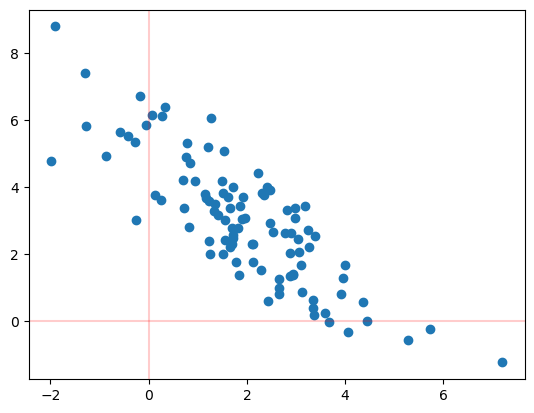

In [15]:
import matplotlib.pyplot as plt

# I added two red lines true the 0,0 axis for easier visualization of centering
plt.axhline(color="red", alpha=0.2)
plt.axvline(color="red", alpha=0.2)

plt.scatter(X[:, 0], X[:, 1])

### Visualize the centered data
Notice that the data visualized above is not centered on the origin (0,0). Use the function defined above to center the data, and the replot it.

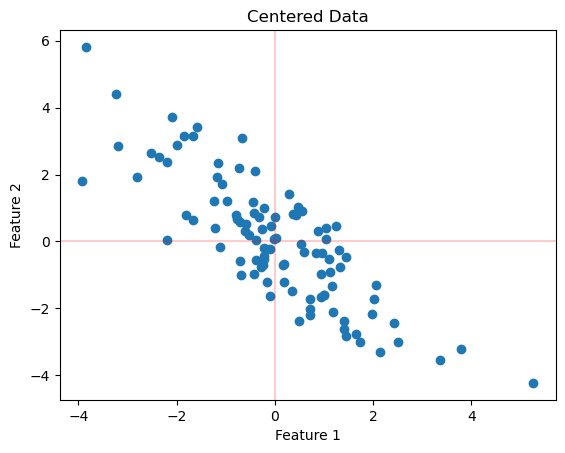

In [16]:
centered_X = center_data(X)

# Step 3: Visualize the centered data
plt.scatter(centered_X[:, 0], centered_X[:, 1])
plt.axhline(color="red", alpha=0.2)
plt.axvline(color="red", alpha=0.2)
plt.title("Centered Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Visualize the first eigenvector
Visualize the vector defined by the first eigenvector.
To do this you need:
- Use the *PCA()* function to recover the eigenvectors
- Plot the centered data as done above 
- The first eigenvector is a 2D vector (x0,y0). This defines a vector with origin in (0,0) and head in (x0,y0). Use the function *plot()* from matplotlib to plot a line over the first eigenvector.

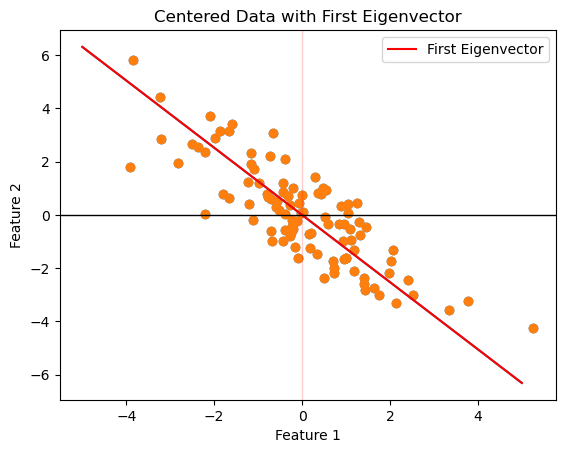

In [17]:
pca_eigvec, _ = pca(X, m=2)
first_eigvec = pca_eigvec[:, 0]

plt.scatter(centered_X[:, 0], centered_X[:, 1])

x = np.linspace(-5, 5, 1000)
y = first_eigvec[1]/first_eigvec[0] * x
plt.plot(x, y)

# Step 2: Compute PCA and get the eigenvectors
pca_eigvec, _ = pca(X, m=2)  # We take two principal components (since it's 2D)

# The first eigenvector
first_eigvec = pca_eigvec[:, 0]

# Step 3: Visualize the centered data
plt.scatter(centered_X[:, 0], centered_X[:, 1])

# Step 4: Plot the first eigenvector
x = np.linspace(-5, 5, 1000)
y = first_eigvec[1] / first_eigvec[0] * x  # Equation of the line defined by the eigenvector
plt.plot(x, y, color="red", label="First Eigenvector")

# Step 5: Add axis lines for better visualization
plt.axhline(0, color='black', linewidth=1)  # Horizontal line (y = 0)
plt.axvline(0, color='red', linewidth=1, alpha=0.2)  # Vertical line (x = 0), 80% transparent

# Final plot settings
plt.title("Centered Data with First Eigenvector")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

### Visualize the PCA projection
Finally, use the *PCA()* algorithm to project on a single dimension and visualize the result using again the *scatter()* function.

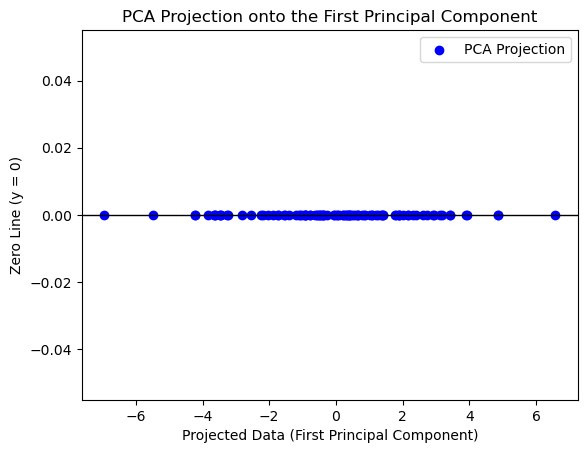

In [18]:
projected_data = centered_X @ first_eigvec  # Projection of data onto the first eigenvector

# Step 4: Visualize the projection
plt.scatter(projected_data, np.zeros_like(projected_data), color='blue', label="PCA Projection")

# Step 5: Add axis lines for better visualization
plt.axhline(0, color='black', linewidth=1)  # Horizontal line (y = 0)

# Final plot settings
plt.title("PCA Projection onto the First Principal Component")
plt.xlabel("Projected Data (First Principal Component)")
plt.ylabel("Zero Line (y = 0)")
plt.legend()
plt.show()

## Part 1.3: Evaluation - When are the results of PCA sensible?
So far we have used PCA on synthetic data. Let us now imagine we are using PCA as a pre-processing step before a classification task. This is a common setup with high-dimensional data. We explore when the use of PCA is sensible.

### Loading the first set of labels
The function *get_synthetic_labeled_data_1()* from the module *data_assignment3* provides a first labeled dataset.

In [19]:
X, y = data_assignment3.get_synthetic_labeled_data_1()

### Running PCA
Process the data using the PCA algorithm and project it in one dimension. Plot the labeled data using *scatter()* before and after running PCA. Comment on the results.

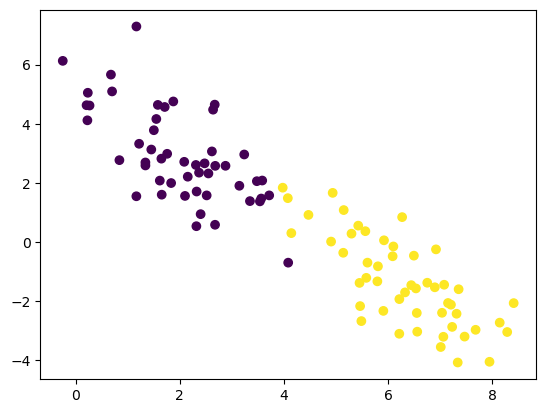

<Figure size 640x480 with 0 Axes>

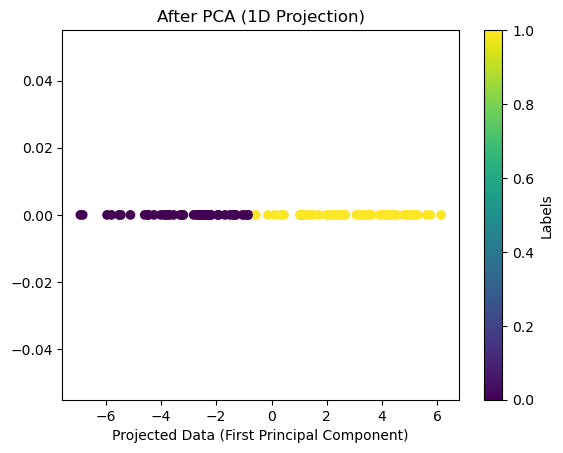

In [20]:
# before PCA
plt.scatter(X[:, 0], X[:, 1], c=y[:, 0])

# after PCA
plt.figure()

# Center the data
centered_X = center_data(X)

# Compute PCA and project the data onto the first principal component
pca_eigvec, _ = pca(X, m=1)  # Project onto 1 dimension

# Project the data onto the first principal component (first eigenvector)
first_eigvec = pca_eigvec[:, 0]
projected_data = centered_X @ first_eigvec  # Projection of data onto the first eigenvector

# Visualize the projected data after PCA
plt.figure()
plt.scatter(projected_data, np.zeros_like(projected_data), c=y[:, 0], cmap='viridis')
plt.title("After PCA (1D Projection)")
plt.xlabel("Projected Data (First Principal Component)")
plt.colorbar(label="Labels")
plt.show()

**Comment:** Before PCA: the data is spread across multiple dimensions (x axis and y axis), you see the scatterplot clearly separated with one small outlier around (5, -1)

After PCA: the data is now all on a single line (one dimension), since the classes where very well separated, across the x axis, you can see there's a clear separation between yellow and dark purple

### Loading the second set of labels
The function *get_synthetic_labeled_data_2()* from the module *data_assignment3* provides a second labeled dataset.

In [21]:
X, y = data_assignment3.get_synthetic_labeled_data_2()

### Running PCA
As before, process the data using the PCA algorithm and project it in one dimension. Plot the labeled data using *scatter()* before and after running PCA. Comment on the results.

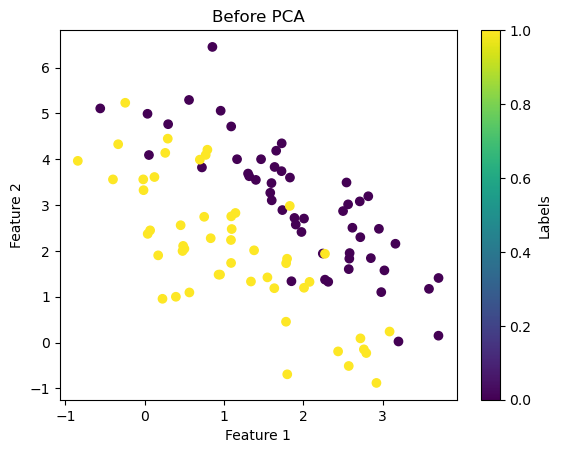

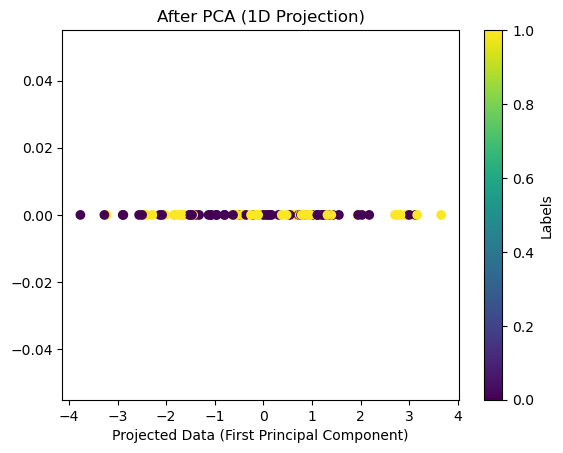

In [22]:
# Step 1: Visualize the data before PCA
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y[:, 0], cmap='viridis')
plt.title("Before PCA")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Labels")
plt.show()

# Step 2: Center the data
centered_X = center_data(X)

# Step 3: Compute PCA and project the data onto the first principal component
pca_eigvec, _ = pca(X, m=1)  # Project onto 1 dimension

# Step 4: Project the data onto the first principal component (first eigenvector)
first_eigvec = pca_eigvec[:, 0]
projected_data = centered_X @ first_eigvec  # Projection of data onto the first eigenvector

# Step 5: Visualize the projected data after PCA
plt.figure()
plt.scatter(projected_data, np.zeros_like(projected_data), c=y[:, 0], cmap='viridis')
plt.title("After PCA (1D Projection)")
plt.xlabel("Projected Data (First Principal Component)")
plt.colorbar(label="Labels")
plt.show()

**Comment:** Before PCA: again the data is spread across multiple dimensions (x axis and y axis), this time the data is seperated more diagonally, and also a few more outliers compared to the previous dataset

After PCA: again the data is projected into a single dimension and the datapoints are much harder to distuinguish, there really isnt a clear separation but you can still kind of decode that the yellow labels gravitate towards right and purple on the left, though it is not clearly defined at all, and most of the datapoints are in the middle.

How would the result change if you were to consider only the second eigenvector?
What about if you were to consider both eigenvectors?

**Answer**: if we consider the second eigenvector, it represents the second greatest variance in the data, meaning that if we project it we would be capturing the variation along the Y-axis of the first eigenvector, which would lead to better results becuase the data is more separated diagonally, and the first eigenvector is a line that is plotted on that diagonal because it gives the most covariance. So I believe that the second eigenvector will reveal the datapoints and be able to diffrentiate the datapoints more clearly than the first eigenvector (PC1)

Both eigenvectors: if we conside both eigenvectors we will still have a 2d space instead of reducing it to 1D. It would better preserve/showcase the structure of the original data but I would say it beats the purpose of reducing dimensionality.

## Part 1.4: Case study 1 - PCA for visualization

The [*iris* flower dataset](https://en.wikipedia.org/wiki/Iris_flower_data_set) is one of the oldest and best known data collections used for machine learning. It consists of 50 samples from each of three species of iris flowers (*Iris setosa, Iris virginica and Iris versicolor*). Four features were measured from each sample: sepal length, sepal width, petal length and petal width, all in centimeters.

Visualizing a 4-dimensional dataset is impossible; therefore we will use PCA to project our data in 2 dimensions and visualize it.

### Loading the data
The function *get_iris_data()* from the module *data_assignment3* returns the *iris* dataset. It returns a data matrix of dimension [150x4] and a label vector of dimension [150].

In [23]:
X, y = data_assignment3.get_iris_data()

### Visualizing the data by selecting features
Try to visualize the data (using label information) by randomly selecting two out of the four features of the data. You may try different pairs of features.

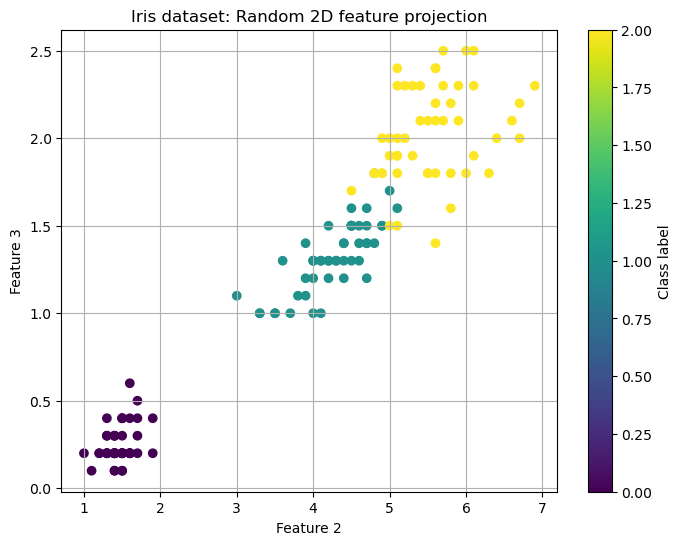

In [24]:
# Randomly pick two feature indices (from 0 to 3)
np.random.seed(0)  # Optional, for reproducibility
feature_indices = np.random.choice(4, size=2, replace=False)

# Select those features
X_selected = X[:, feature_indices]

# Plot the selected features
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_selected[:, 0], X_selected[:, 1], c=y, cmap='viridis')
plt.xlabel(f'Feature {feature_indices[0]}')
plt.ylabel(f'Feature {feature_indices[1]}')
plt.title('Iris dataset: Random 2D feature projection')
plt.colorbar(scatter, label='Class label')
plt.grid(True)
plt.show()

### Visualizing the data by PCA
Process the data using PCA and visualize it (using label information). Compare with the previous visualization and comment on the results.

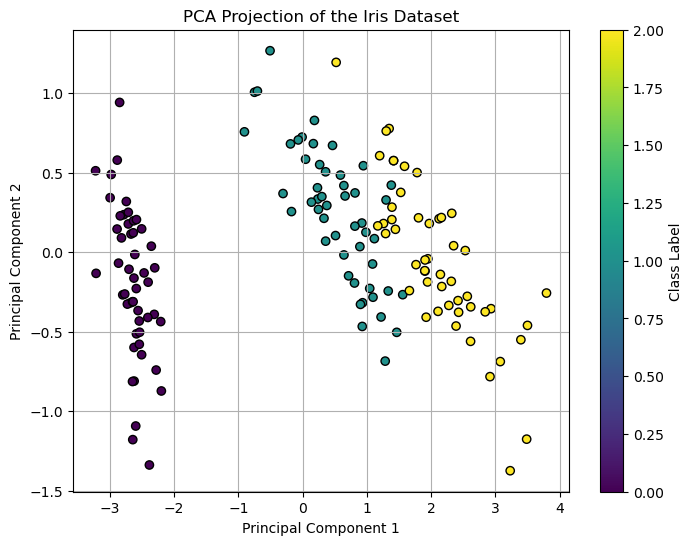

In [25]:
# Apply PCA to reduce to 2 dimensions
_, P = pca(X, 2)

# Visualize the projected data
plt.figure(figsize=(8, 6))
plt.scatter(P[:, 0], P[:, 1], c=y, cmap='viridis', edgecolor='k')
plt.title("PCA Projection of the Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.colorbar(label='Class Label')
plt.show()

**Comment:** in the first visualization, we have to select two out of 4 features, meaning that to visualize the data we had to randomly get rid of extra dimensions, in the first visualization you can see 3 class labels, the dark purple is clearly separated and green & yellow labels do bleed into each other but they're still very distinguishable/separatable

the second plot, after applying PCA we can see that the data is evaluated into principal components, each showcasing their covariance. You can see that principal component 1 has the most variance, because if you would only project that axis, then you can clearly see the difference between the labels purple, yellow and green, meanwhile PCA2 has less variance because all the datapoints are clustered togheter making it harder to distuinguish between them.

## Part 1.5: Case study 2 - PCA for compression
We now consider the *faces in the wild (lfw)* dataset, a collection of pictures (N=1280) of people. Each pixel in the image is a feature (M=2914).

### Loading the data
The function *get_lfw_data()* from the module *data_assignment3* returns the *lfw* dataset. It returns a data matrix of dimension [1280x2914] and a label vector of dimension [1280]. It also returns two parameters, $h$ and $w$, reporting the height and the width of the images (these parameters are necessary to plot the data samples as images). Beware, it might take some time to download the data. Be patient :) 

In [26]:
X, y, h, w = data_assignment3.get_lfw_data()

### Inspecting the data
Choose one datapoint to visualize (first coordinate of the matrix $X$) and use the function [imshow()](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.imshow.html) to plot and inspect some of the pictures.

Notice that the first argument of *imshow* is the image to be plotted; the image must be provided as a rectangular matrix, therefore we reshape a sample from the matrix $X$ to have height $h$ and width $w$. The parameter *cmap* specifies the color coding; in our case we will visualize the image in black-and-white with different gradations of grey.

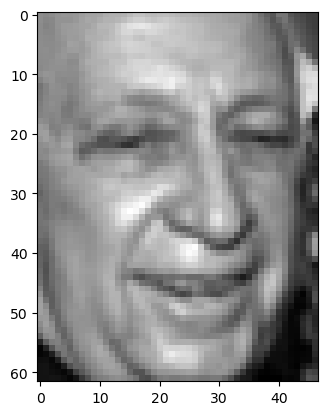

In [27]:
image_number = 4    # display the 4th image of the collection
plt.imshow(X[image_number, :].reshape((h, w)), cmap=plt.cm.gray) # we get this amazing picture of alfred hitchcock (btw watch rear window)

### Implementing a compression-decompression function
Implement a function that first uses PCA to project samples in low-dimensions, and then reconstruct the original image.

*Hint:* Most of the code is the same as the previous PCA() function you implemented.

In [28]:
def encode_decode_pca(A, m):
    # Step 1: Center the data
    centered_A = center_data(A)

    # Step 2: Compute covariance matrix
    cov_matrix = compute_covariance_matrix(centered_A)

    # Step 3: Compute eigenvalues and eigenvectors
    eigval, eigvec = compute_eigenvalue_eigenvectors(cov_matrix)

    # Step 4: Sort them
    sorted_eigval, sorted_eigvec = sort_eigenvalue_eigenvectors(eigval, eigvec)

    # Step 5: Select top m eigenvectors (principal components)
    pca_eigvec = sorted_eigvec[:, :m]

    # Step 6: Project the data into lower dimensions
    low_dim = centered_A @ pca_eigvec

    # Step 7: Reconstruct the data (project back)
    Ahat = low_dim @ pca_eigvec.T

    # Step 8: Add the mean back
    mean_A = np.mean(A, axis=0)
    Ahat += mean_A

    return Ahat

### Compressing and decompressing the data
Use the implemented function to encode and decode the data by projecting on a lower dimensional space of dimension 200 (m=200).

In [29]:
# Compress and reconstruct the LFW dataset using 200 principal components
Xhat = encode_decode_pca(X, m=200)

### Inspecting the reconstructed data
Use the function *imshow* to plot and compare original and reconstructed pictures. Comment on the results.

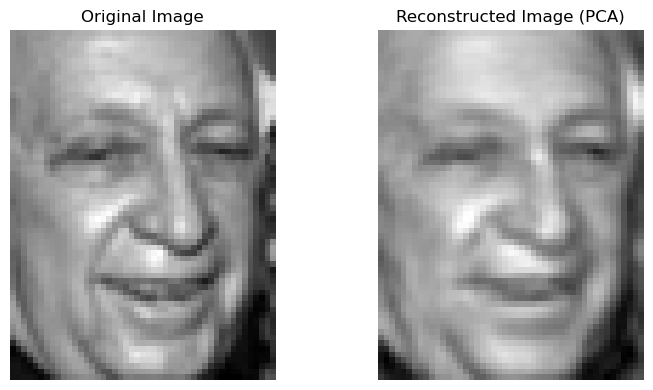

In [30]:
# Choose the image index to inspect
image_index = 4

# Plot original image
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(X[image_index].reshape((h, w)), cmap='gray')
plt.title("Original Image")
plt.axis('off')

# Plot reconstructed image
plt.subplot(1, 2, 2)
plt.imshow(Xhat[image_index].reshape((h, w)), cmap='gray')
plt.title("Reconstructed Image (PCA)")
plt.axis('off')

plt.tight_layout()
plt.show()

**Comment:** the image is reconstructed as a linear combination of the eigenfaces, we can notice that the face is more smoother, meaning that there isnt as much of darker detailes as to the picture on the left, but the overal facial structure such as eyes, nose, mouth etc.

### Evaluating different compressions
Use the previous setup to generate compressed images using different values of low dimensions in the PCA algorithm (e.g.: 20, 100, 200, 500, 1000). Plot and comment on the results. You can use `plt.subplot(n_rows, n_cols, position)` and `plt.title(titlestring)` to get a nice plot.

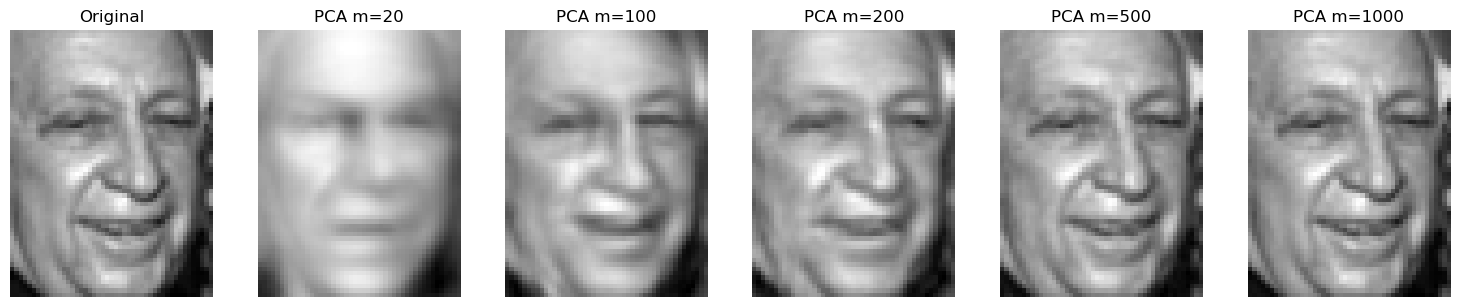

In [33]:
# Different dimensions to test
dims = [20, 100, 200, 500, 1000]

# Plot setup
plt.figure(figsize=(15, 6))
plt.subplot(2, len(dims)+1, 1)
plt.imshow(X[image_index].reshape(h, w), cmap='gray')
plt.title("Original")
plt.axis('off')

# Loop through dimensions and plot reconstructions
for i, m in enumerate(dims):
    Xhat = encode_decode_pca(X, m)
    plt.subplot(2, len(dims)+1, i + 2)
    plt.imshow(Xhat[image_index].reshape(h, w), cmap='gray')
    plt.title(f"PCA m={m}")
    plt.axis('off')

plt.tight_layout()
plt.show()

**Comment:** PCA m=20: very blurry, hard to recognize the individual. 
100: more clearer with more detail.
every iteration after that decreases the compression artifacts.
the difference between 500 and 1000 is very hard to distuinguish, they look very alike

## Part 1.6: PCA tuning (compulsory for Master students only)
If we use PCA for compression or decompression, it may be not trivial to decide how many dimensions to keep. In this section we review a principled way to decide how many dimensions to keep.

The number of dimensions to keep is the only *hyper-parameter* of PCA. A method designed to decide how many dimensions/eigenvectors is the *proportion of variance*:
$$ \textrm{POV}=\frac{\sum_{i=1}^{m}{\lambda_{i}}}{\sum_{j=1}^{M}{\lambda_{j}}}, $$
where $\lambda$ are eigenvalues, $M$ is the dimensionality of the original data, and $m$ is the chosen lower dimensionality. 

Using the $POV$ formula we may select a number $m$ of dimensions/eigenvalues so that the proportion of variance is, for instance, equal to 95%.

Implement a new PCA for encoding and decoding that receives in input not the number of dimensions for projection, but the amount of proportion of variance to be preserved.

In [34]:
def encode_decode_pca_with_pov(A, p):
    # Center the data
    centered_A = center_data(A)
    
    # Compute covariance matrix
    cov_matrix = compute_covariance_matrix(A)
    
    # Compute eigenvalues and eigenvectors
    eigval, eigvec = compute_eigenvalue_eigenvectors(cov_matrix)
    
    # Sort them in descending order
    sorted_eigval, sorted_eigvec = sort_eigenvalue_eigenvectors(eigval, eigvec)
    
    # Compute cumulative proportion of variance
    total_variance = np.sum(sorted_eigval)
    cumulative_variance = np.cumsum(sorted_eigval)
    pov = cumulative_variance / total_variance
    
    # Find the number of components m that captures at least p variance
    m = np.searchsorted(pov, p) + 1  # +1 since indices start at 0
    
    # Select top-m eigenvectors
    pca_eigvec = sorted_eigvec[:, :m]
    
    # Project and reconstruct
    P = centered_A @ pca_eigvec
    Ahat = P @ pca_eigvec.T + np.mean(A, axis=0)  # Add back the mean

    return Ahat, m

Import the `lfw` dataset again. Use the implemented function to encode and decode the data by projecting on a lower dimensional space such that `POV=0.95`. Use the function `imshow` to plot and compare original and reconstructed pictures. Comment on the results.

Selected dimensions: 184


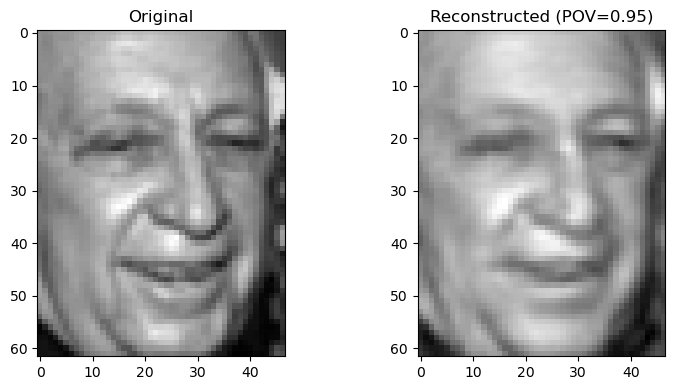

In [37]:
X, y, h, w = data_assignment3.get_lfw_data()

Xhat, m = encode_decode_pca_with_pov(X, 0.95)
print("Selected dimensions:", m)

image_number = 4

# Plot the images here
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(X[image_number, :].reshape((h, w)), cmap=plt.cm.gray)

plt.subplot(1, 2, 2)
plt.title("Reconstructed (POV=0.95)")
plt.imshow(Xhat[image_number, :].reshape((h, w)), cmap=plt.cm.gray)

plt.tight_layout()
plt.show()

**Comment:** the image quality is around the same as m=200 in the previous call, but it shows that 95% variance is enough to retain the main characteristics of the face while reducing dimensionality drastically.

# Part 2: K-Means Clustering
In this section you will use the *k-means clustering* algorithm to perform unsupervised clustering. Then you will perform a qualitative assessment of the results.

## Part 2.1: Applying K-Means and Qualitative Assessment

### Importing scikit-learn library
We start importing the module `sklearn.cluster.KMeans` from the standard machine learning library `scikit-learn`.

In [38]:
from sklearn.cluster import KMeans

### Loading the data
We will use once again the *iris* data set. Start by loading the dataset again.

In [39]:
X, y = data_assignment3.get_iris_data()

### Projecting the data using PCA
To allow for visualization, we project our data in two dimensions as we did previously. This step is not necessary, and we may want to try to use *k-means* later without the PCA pre-processing. But to start, we use PCA, as this will allow for an easy visualization.

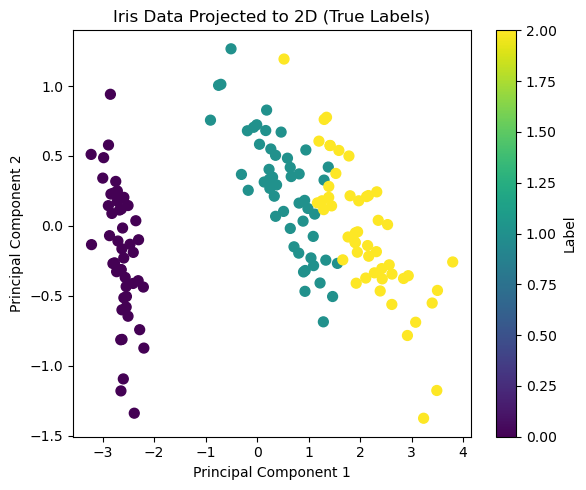

In [40]:
# Project the data using PCA to 2 dimensions
_, X_pca = pca(X, 2)  # Use your custom PCA function

# Visualize the PCA-projected data with true labels
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=50)
plt.title("Iris Data Projected to 2D (True Labels)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Label')
plt.tight_layout()
plt.show()

### Running k-means
Use the class *KMeans* to fit and predict the output of the *k-means* algorithm on the projected data (note that we don't use the true labels `y` here). Run the algorithm using the following values of $k=\{2,3,4,5\}$. 

In [41]:
k_values = [2, 3, 4, 5]
y_hats = []

for k in k_values:
    # Initialize KMeans with current k
    kmeans = KMeans(n_clusters=k, random_state=42)
    
    # Fit to the PCA-projected data and predict cluster labels
    y_hat = kmeans.fit_predict(X_pca)
    
    # Store predictions
    y_hats.append(y_hat)

### Qualitative assessment
Plot the results of running the k-means algorithm, compare with the true labels, and comment.

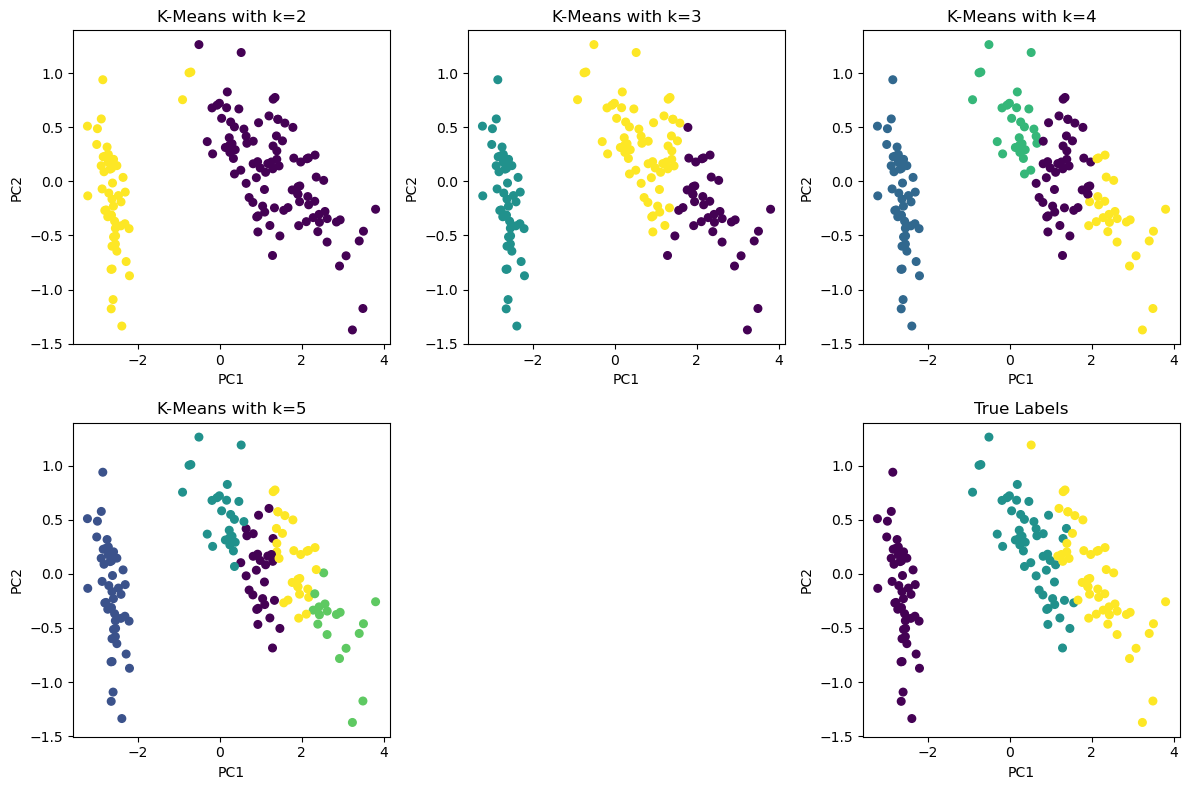

In [43]:
# Titles for subplot comparison
titles = [f'K-Means with k={k}' for k in k_values]

plt.figure(figsize=(12, 8))

# Plot clustering results
for i, y_hat in enumerate(y_hats):
    plt.subplot(2, 3, i+1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_hat, cmap='viridis', s=30)
    plt.title(titles[i])
    plt.xlabel('PC1')
    plt.ylabel('PC2')

# Plot true labels for comparison
plt.subplot(2, 3, 6)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=30)
plt.title('True Labels')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.tight_layout()
plt.show()

**Comment:** the results varies based on the amount of K's, when k=3 it is closer to the true label, it has a very easy time on clusters that are far from eachother, but when theres overlapping or closer data, the k-means algorithm may strugge to classify closer to the true labels.

with K's over or under you can notice over/under segmentation. I think that if you want to do k-mean clustering you should know already the original datasets amount of labels, but this could make little sense since the point of this unsupervised learning is to find the labels by the algorithm and they're not known unlike in supervised learning.

## Part 2.2: Quantitative Assessment of K-Means

Above, we used k-means for clustering and assessed the results qualitatively by visualizing them. However, we often want to measure in a quantitative way how good a clustering is. To do this, we will use a classification task to **evaluate numerically how good the learned clusters are for all the different values of k you used above (2 to 5)**.

Informally, our evaluation will work as follows: For each of our clusterings ($k=2$ to $k=5$), we will try to learn a mapping from the identified clusters to the correct labels of our datapoints. The reason this can be a sensible evaluation, is that to learn a good mapping, we have to have identified clusters that correspond to the actual classes in our data. We will in other words train 4 different classification models (one for each $k$ value), where the input to our classifier is the cluster each datapoint belongs to, and the target is the correct class for this datapoint. In other words, **we aim to learn to classify datapoints as well as possible with the only information available to the classifier being the cluster that datapoint belongs to**. For some values of k, we will get poorly performing classifiers, indicating that this clustering has not revealed the correct class division in our data.

In practice, you will do the following: Reload the *iris* dataset. Import a standard `LogisticRegression` classifier from the module `sklearn.linear_model`. Use the k-means representations learned previously (`yhats[2],...,yhats[5]`) and the true label to train the classifier. Evaluate your model on the training data (we do not have a test set, so this procedure will assess the model fit instead of generalization) using the `accuracy_score()` function from the `sklearn.metrics` module. Plot a graph showing how the accuracy score varies when changing the value of $k$. Comment on the results.

- Train a Logistic regression model using the first two dimensions of the PCA of the iris data set as input, and the true classes as targets.
- Report the model fit/accuracy on the training set.
- For each value of K:
  - One-Hot-Encode the classes outputed by the K-means algorithm.
  - Train a Logistic regression model on the K-means classes as input vs the real classes as targets.
  - Calculate model fit/accuracy vs. value of K.
- Plot your results in a graph and comment on the K-means fit.

Baseline PCA + Logistic Regression Accuracy: 0.9666666666666667


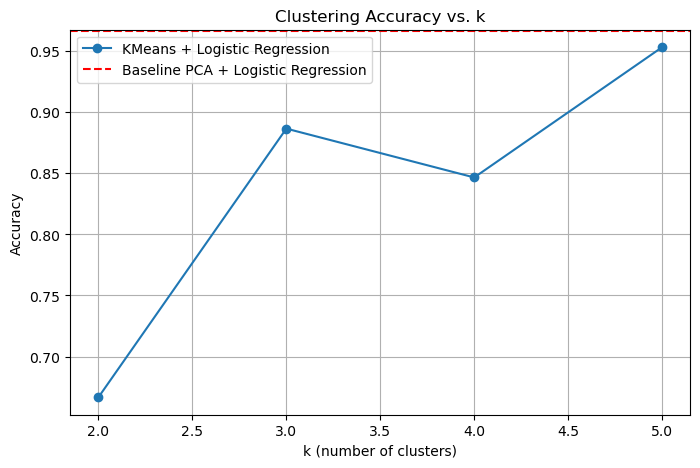

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.preprocessing import OneHotEncoder

# 1. Baseline Logistic Regression on 2D PCA with true labels
logreg = LogisticRegression(max_iter=200)
logreg.fit(X_pca, y)
baseline_acc = metrics.accuracy_score(y, logreg.predict(X_pca))
print("Baseline PCA + Logistic Regression Accuracy:", baseline_acc)

# 2. Logistic regression using K-means outputs
k_values = [2, 3, 4, 5]
kmeans_accuracies = []

for i, k in enumerate(k_values):
    y_hat = y_hats[i].reshape(-1, 1)  # reshape for OneHotEncoder
    encoder = OneHotEncoder(sparse_output=False)
    X_kmeans_encoded = encoder.fit_transform(y_hat)

    logreg = LogisticRegression(max_iter=200)
    logreg.fit(X_kmeans_encoded, y)
    preds = logreg.predict(X_kmeans_encoded)
    acc = metrics.accuracy_score(y, preds)
    kmeans_accuracies.append(acc)

# 3. Plotting
plt.figure(figsize=(8, 5))
plt.plot(k_values, kmeans_accuracies, marker='o', label='KMeans + Logistic Regression')
plt.axhline(baseline_acc, color='r', linestyle='--', label='Baseline PCA + Logistic Regression')
plt.xlabel('k (number of clusters)')
plt.ylabel('Accuracy')
plt.title('Clustering Accuracy vs. k')
plt.legend()
plt.grid(True)
plt.show()

**Comment:** The graph shows how the clustering accuracy changes the more values of K we add. Surprisingly the best accuracy is K=5 as that's closest to baseline PCA. What's interesting is that we're using unsupervised learning methods to train the model on the data, but then using supervised methods, such as logistic linear regression to evaluate if the model is performing good or poorly. This has a very grey area wheter you call this unsupervised learning, but I am guessing since the training data is not using labels and those labels are only used in evaluation then it's counted as unsupervised learning.

# Conclusions 

In this notebook we studied **unsupervised learning** considering two important and representative algorithms: **PCA** and **k-means**.

First, we implemented the PCA algorithm step by step; we then ran the algorithm on synthetic data in order to see its working and evaluated when it makes sense to use it and when it doesn't. We then considered two typical uses of PCA: for **visualization** on the *iris* dataset, and for **compression-decompression** on the *lfw* dataset. We also looked at an additional question that arises when using PCA: the problem of **selection of hyper-parameters**, that is, how to select the optimal hyper-parameter of our algorithm for a particular task.

We then moved to consider the k-means algorithm. In this case we used the implementation provided by *scikit-learn* and applied it to another prototypical unsupervised learning problem: **clustering**. We processed the *iris* dataset with *k-means* and evaluated the results visually. We also considered the problem of **quantitative evaluation** of the results, that is, how to measure the performance or usefulness of k-means clustering on a downstream task (classifying the *iris* samples into their species).